# Extension with Stylistic Diversity (D_style)

- Based on a compact stylometric feature vector (11 features)
- Captures *how* a text sounds (tone, register, rhythm) rather than *what* it says (D_sem), *which words* are used (D_lex), *how sentences are built* grammatically (D_syn)

**Features:**
1. Function-word frequency distribution (cosine distance over the NLTK English stopword list)
2. Mean sentence length
3. Sentence length variance (rhythm / burstiness)
4. Flesch Reading Ease
5. Comma density (commas per sentence)
6. Adjective + adverb-to-content-word ratio (via spaCy POS tags)
7. Mean word length in syllables
8. Dialogue ratio (dialogue turns per sentence)
9. Punctuation expressivity (?, !, ellipses per sentence)
10. Mean paragraph length (words per paragraph)
11. Sentence-initial pronoun ratio

**Metric formula:**
$$D_{\text{style}} = \frac{1}{\binom{n}{2}} \sum_{i < j} \| \mathbf{z}_i - \mathbf{z}_j \|_2$$
where $\mathbf{z}_i$ is the z-standardized stylistic feature vector of text $i$.

### Data
Generated data from `data_generation/generations/` switchable via `DOMAIN`:
- **`storytelling_n200`**: WritingPrompts (Fan et al., 2018) test split, 200 prompts x 4 LLMs x 5 samples + >=5 human reference stories/prompt
- **`translation_ref3`**: Par3 (Karpinska et al., 2022) pooled German/Russian/Chinese source books, 200 paragraphs x 4 LLMs x 5 samples + >=3 human translations/paragraph
- **`translation_ref4`**: Par3 (Karpinska et al., 2022) pooled German/Russian/Chinese source books, 200 paragraphs x 4 LLMs x 5 samples + >=4 human translations/paragraph

In [19]:
# Load libraries
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from itertools import combinations
from scipy.spatial.distance import cosine
from scipy.stats import kruskal, mannwhitneyu
import spacy
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
import textstat
import warnings
warnings.filterwarnings('ignore')


In [20]:
# Download NLTK resources (stopwords)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

# Load spaCy model
nlp = spacy.load('en_core_web_sm')

# Print-oriented plotting defaults: figures are sized close to their intended
# print width (~\linewidth = 160mm = 6.3in) so text isn't tiny once embedded in
# the thesis PDF -- see figsize/fontsize choices per plotting cell below
plt.rcParams.update({'figure.dpi': 150, 'font.size': 11, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'legend.fontsize': 10,
                     'xtick.labelsize': 10, 'ytick.labelsize': 10})

In [42]:
# Configuration
DOMAIN = 'translation_ref3'  # 'storytelling_n200', 'translation_ref3' or 'translation_ref4'

MIN_SENTENCES = 3           # minimum sentences required to include a text
SOURCES = ['human', 'llama', 'mistral', 'qwen', 'gemma']
N_PROMPTS = 200

DOMAIN_CONFIG = {
    'storytelling_n200': dict(
        data_dir='storytelling_n200',
        gen_file=lambda key: f'writingprompts_{key}_n5.jsonl',
        prompts_file='prompts_sample.jsonl',
        text_field='story',
        human_field='human_stories',
    ),
    'translation_ref3': dict(
        data_dir='translation_ref3',
        gen_file=lambda key: f'par3_{key}_n5.jsonl',
        prompts_file='par3_paragraphs_sample.jsonl',
        text_field='translation',
        human_field='human_translations',
    ),
    'translation_ref4': dict(
        data_dir='translation_ref4',
        gen_file=lambda key: f'par4_{key}_n5.jsonl',
        prompts_file='par4_paragraphs_sample.jsonl',
        text_field='translation',
        human_field='human_translations',
    ),
}

FIG_DIR = Path(f'../../figures/stylistic_diversity/{DOMAIN}')
FIG_DIR.mkdir(parents=True, exist_ok=True)

TABLE_DIR = Path(f'../../metrics/02_stylistic_diversity/tables/{DOMAIN}')
TABLE_DIR.mkdir(parents=True, exist_ok=True)

SOURCE_COLORS = {'human': '#cb1f73', 'gemma': '#fcc72d', 'llama': '#ea6d3d', 'mistral': '#e03a3c', 'qwen': '#383a6b'}

# Function-word set: NLTK's English stopword list (Bird, Klein & Loper, 2009) —
# Restricted to standalone alphabetic entries -> this also drops contraction fragments
_CONTRACTION_FRAGMENTS = {
    'ain', 'aren', 'couldn', 'didn', 'doesn', 'don', 'hadn', 'hasn', 'haven',
    'isn', 'mightn', 'mustn', 'needn', 'shan', 'shouldn', 'wasn', 'weren',
    'won', 'wouldn', 'd', 'll', 'm', 'ma', 'o', 're', 's', 't', 've', 'y',
}
FUNCTION_WORDS = sorted(
    w for w in stopwords.words('english')
    if w.isalpha() and w not in _CONTRACTION_FRAGMENTS
)

print("Configuration:")
print(f"  Domain:                 {DOMAIN}")
print(f"  Function word set size: {len(FUNCTION_WORDS)}")
print(f"  Min sentences:          {MIN_SENTENCES}")


Configuration:
  Domain:                 translation_ref3
  Function word set size: 124
  Min sentences:          3


## Load Dataset

In [43]:
# Repo root importable regardless of the kernel's working directory
def find_repo_root(start=None):
    start = Path(start or Path.cwd())
    for p in [start, *start.parents]:
        if (p / 'metrics_lib').is_dir() and (p / 'data_generation' / 'generations').is_dir():
            return p
    raise FileNotFoundError("Could not locate the repo root (expected 'metrics_lib/' and "
                             "'data_generation/generations/')")

REPO_ROOT = find_repo_root()
cfg = DOMAIN_CONFIG[DOMAIN]
DATA_DIR = REPO_ROOT / 'data_generation' / 'generations' / cfg['data_dir']
print(f"DOMAIN = {DOMAIN!r}  ({DATA_DIR})")

# Prompt order + human reference texts, from the shared prompts file (one row per prompt/paragraph)
prompt_ids, human_raw = [], {}
with open(DATA_DIR / cfg['prompts_file']) as f:
    for line in f:
        r = json.loads(line)
        prompt_ids.append(r['prompt_id'])
        human_raw[r['prompt_id']] = r[cfg['human_field']]
prompt_ids = prompt_ids[:N_PROMPTS]
prompt_index = {pid: i for i, pid in enumerate(prompt_ids)}

rows = []
for pid, i in prompt_index.items():
    val = human_raw[pid]
    human_texts = list(val.values()) if isinstance(val, dict) else list(val)
    for story_id, text in enumerate(human_texts):
        rows.append({'prompt_id': i, 'source': 'human', 'story_id': story_id, 'text': text})

# Generated texts per model (4 LLMs x N_PROMPTS x 5 samples)
n_dropped = {}
for source in SOURCES:
    if source == 'human':
        continue
    dropped, story_counters = 0, {}
    with open(DATA_DIR / cfg['gen_file'](source)) as f:
        for line in f:
            r = json.loads(line)
            pid = r['prompt_id']
            if pid not in prompt_index:
                continue
            if r.get('finish_reason') == 'length' or not r.get('language_ok', True):
                dropped += 1
                continue
            i = prompt_index[pid]
            story_id = story_counters.get(i, 0)
            rows.append({'prompt_id': i, 'source': source, 'story_id': story_id, 'text': r[cfg['text_field']]})
            story_counters[i] = story_id + 1
    n_dropped[source] = dropped

df = pd.DataFrame(rows)
print(f"Loaded: {len(df)} texts ({df['prompt_id'].nunique()} prompts x {len(SOURCES)} sources)")
print(f"Dropped (quality filter): {n_dropped}")
df.head()

DOMAIN = 'translation_ref3'  (/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/Masterthesis/data_generation/generations/translation_ref3)
Loaded: 4403 texts (200 prompts x 5 sources)
Dropped (quality filter): {'llama': 9, 'mistral': 27, 'qwen': 166, 'gemma': 64}


,prompt_id,source,story_id,text
0,0,human,0,Though – what am I saying? – everyone does it;...
1,0,human,1,"Why do I say that, though? Everybody does it –..."
2,0,human,2,"But, gentlemen, whoever can pride himself on h..."
3,1,human,0,K. waited from day to day throughout the follo...
4,1,human,1,DURING the next week K. waited day after day f...


In [44]:
print(f"\nSources: {df['source'].unique()}")
print(f"Prompts: {df['prompt_id'].nunique()}")


Sources: <ArrowStringArray>
['human', 'llama', 'mistral', 'qwen', 'gemma']
Length: 5, dtype: str
Prompts: 200


## Feature Extraction

- Each feature is computed per text
- Feature 1 is a 124-dim distribution handled separately via cosine distance (not z-standardized like the others, since it's already a normalized distribution)
- Features 2–11 are scalars (10 features)

In [45]:
def count_syllables(word: str) -> int:
    """Simple heuristic syllable counter (vowel-group based)"""

    # Convert to lowercase and define vowels
    word = word.lower()
    vowels = 'aeiouy'

    count = 0
    prev_was_vowel = False
    
    # Count vowel groups
    for ch in word:
        is_vowel = ch in vowels
        if is_vowel and not prev_was_vowel:
            count += 1
        prev_was_vowel = is_vowel
    
    # Adjust for silent 'e' at the end of words
    if word.endswith('e') and count > 1:
        count -= 1
    
    return max(count, 1)


def extract_style_features(text: str, min_sentences: int = MIN_SENTENCES):
    """
    Extract 11-feature stylistic vector for a single text.
    Returns a dict or None if the text is too short to analyze.
    """
    # Tokenize sentences and filter out empty sentences
    sentences = sent_tokenize(text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 0]
    if len(sentences) < min_sentences:
        return None

    # Tokenize words and filter to alphabetic tokens
    words = word_tokenize(text)
    words_alpha = [w.lower() for w in words if w.isalpha()]
    if len(words_alpha) == 0:
        return None

    # Feature 1: function-word frequency distribution
    fw_counts = np.array([words_alpha.count(fw) for fw in FUNCTION_WORDS], dtype=float)
    fw_dist = fw_counts / (fw_counts.sum() + 1e-9)

    # Feature 2 & 3: sentence length mean & variance (in words)
    sent_lengths = [len(word_tokenize(s)) for s in sentences]
    sent_len_mean = np.mean(sent_lengths)
    sent_len_var = np.var(sent_lengths)

    # Feature 4: Flesch Reading Ease (via textstat)
    flesch = textstat.flesch_reading_ease(text)

    # Feature 5: comma density (commas per sentence)
    comma_count = text.count(',')
    comma_density = comma_count / len(sentences)

    # Feature 6: (adjective + adverb) to content-word ratio via spaCy
    doc = nlp(text)

    # Define content words as nouns, verbs, adjectives, adverbs and proper nouns
    content_pos = {'NOUN', 'VERB', 'ADJ', 'ADV', 'PROPN'}

    # Define adjective and adverb POS tags
    adj_adv_pos = {'ADJ', 'ADV'}

    # Compute the ratio of adjectives and adverbs to content words
    content_tokens = [t for t in doc if t.pos_ in content_pos]
    adj_adv_tokens = [t for t in doc if t.pos_ in adj_adv_pos]
    adj_adv_ratio = len(adj_adv_tokens) / (len(content_tokens) + 1e-9)

    # Feature 7: mean word length in syllables
    syllable_counts = [count_syllables(w) for w in words_alpha]
    mean_syllables = np.mean(syllable_counts)

    # Feature 8: dialogue ratio
    # Count opening quotation marks (straight + curly) as proxy for dialogue turns
    dialogue_turns = text.count('"') + text.count('“')
    dialogue_ratio = dialogue_turns / (len(sentences) + 1e-9)

    # Feature 9: punctuation expressivity (?, !, ellipses per sentence)
    expressive_punct = text.count('?') + text.count('!') + text.count('…') + text.count('...')
    punct_expressivity = expressive_punct / (len(sentences) + 1e-9)

    # Feature 10: mean paragraph length (words per paragraph)
    paragraphs = [p.strip() for p in text.split('\n\n') if len(p.strip()) > 0]
    if len(paragraphs) == 0:
        paragraphs = [text]
    mean_para_length = np.mean([len(word_tokenize(p)) for p in paragraphs])

    # Feature 11: sentence-initial pronoun ratio (via spaCy sentence segmentation)
    spacy_sents = list(doc.sents)
    pron_starts = sum(1 for s in spacy_sents if len(s) > 0 and s[0].pos_ == 'PRON')
    sent_start_pron_ratio = pron_starts / (len(spacy_sents) + 1e-9)

    return {
        'fw_dist': fw_dist,
        'sent_len_mean': sent_len_mean,
        'sent_len_var': sent_len_var,
        'flesch_reading_ease': flesch,
        'comma_density': comma_density,
        'adj_adv_ratio': adj_adv_ratio,
        'mean_syllables': mean_syllables,
        'dialogue_ratio': dialogue_ratio,
        'punct_expressivity': punct_expressivity,
        'mean_para_length': mean_para_length,
        'sent_start_pron_ratio': sent_start_pron_ratio,
    }


features = df['text'].apply(extract_style_features)
df['features'] = features

n_valid = df['features'].notna().sum()
n_invalid = df['features'].isna().sum()
print(f"Valid feature extractions: {n_valid}")
print(f"Skipped (too short):       {n_invalid}")

df_valid = df.dropna(subset=['features']).copy()

Valid feature extractions: 4403
Skipped (too short):       0


In [46]:
# Unpack scalar features into separate columns
scalar_feature_names = [
    'sent_len_mean', 'sent_len_var', 'flesch_reading_ease',
    'comma_density', 'adj_adv_ratio', 'mean_syllables',
    'dialogue_ratio', 'punct_expressivity', 'mean_para_length', 'sent_start_pron_ratio',
]

# Human-readable labels for plot titles
FEATURE_LABELS = {
    'sent_len_mean': 'Mean Sentence Length',
    'sent_len_var': 'Sentence Length Variance',
    'flesch_reading_ease': 'Flesch Reading Ease',
    'comma_density': 'Comma Density',
    'adj_adv_ratio': 'Adjective + Adverb Ratio',
    'mean_syllables': 'Mean Word Length (Syllables)',
    'dialogue_ratio': 'Dialogue Ratio',
    'punct_expressivity': 'Punctuation Expressivity',
    'mean_para_length': 'Mean Paragraph Length',
    'sent_start_pron_ratio': 'Sentence-Initial Pronoun Ratio',
}

for fname in scalar_feature_names:
    df_valid[fname] = df_valid['features'].apply(lambda f: f[fname])

df_valid['fw_dist'] = df_valid['features'].apply(lambda f: f['fw_dist'])

feature_descriptives = df_valid[['source'] + scalar_feature_names].groupby('source').describe().round(3)
feature_descriptives.to_csv(TABLE_DIR / 'feature_descriptives_by_source.csv')
feature_descriptives


sent_len_mean                                                        \
                count    mean    std    min     25%     50%     75%     max   
source                                                                        
gemma           936.0  23.484  8.015  7.083  17.661  21.531  28.429  62.333   
human           669.0  26.302  8.669  7.969  20.143  24.923  30.583  65.750   
llama           991.0  24.067  7.199  7.727  19.200  22.833  28.176  54.417   
mistral         973.0  22.562  6.824  7.381  17.706  21.107  26.500  52.750   
qwen            834.0  22.411  7.226  7.000  17.227  20.883  26.524  48.615   

        sent_len_var           ... mean_para_length          \
               count     mean  ...              75%     max   
source                         ...                            
gemma          936.0  260.417  ...           417.00  2629.0   
human          669.0  323.479  ...           524.00  5508.0   
llama          991.0  245.791  ...           438.50  2212.0   
mistral        973.0  244.859  ...           435.00  2723.0   
qwen           834.0  222.262  ...           467.75  2189.0   

        sent_start_pron_ratio                                                 
                        count   mean    std  min    25%    50%    75%    max  
source                                                                        
gemma                   936.0  0.297  0.148  0.0  0.200  0.286  0.385  0.800  
human                   669.0  0.270  0.152  0.0  0.174  0.250  0.357  0.778  
llama                   991.0  0.293  0.155  0.0  0.182  0.273  0.390  0.800  
mistral                 973.0  0.283  0.156  0.0  0.174  0.263  0.385  0.857  
qwen                    834.0  0.288  0.153  0.0  0.187  0.273  0.385  0.739  

[5 rows x 80 columns]

## Feature Redundancy Analysis

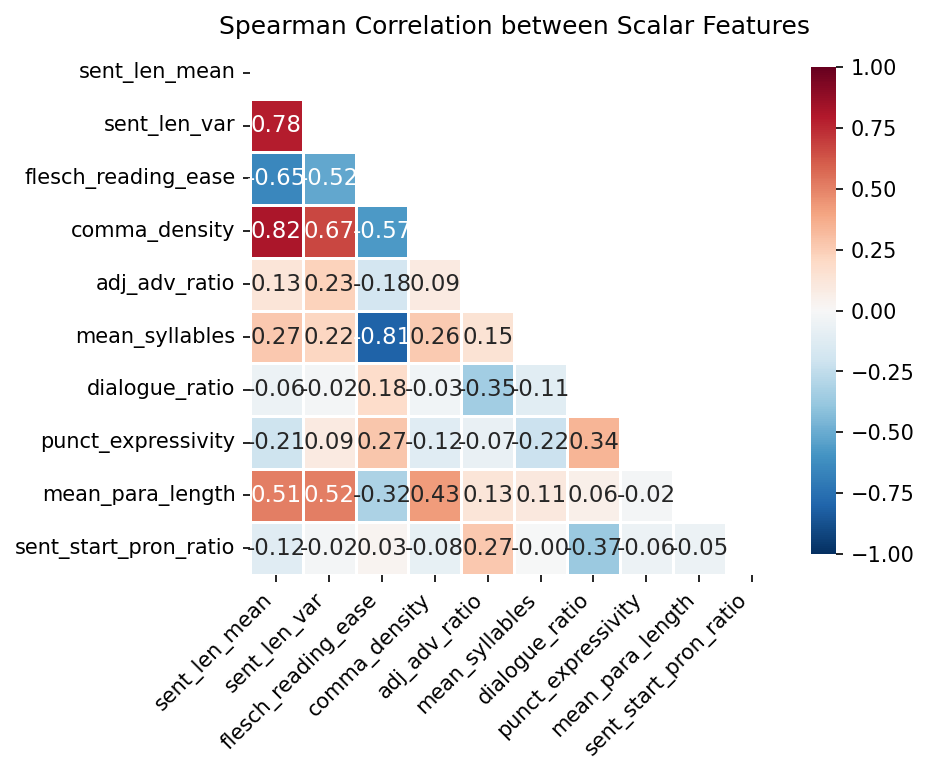

In [47]:
# Compute Spearman correlation matrix for scalar features
corr_matrix = df_valid[scalar_feature_names].corr(method='spearman')
corr_matrix.to_csv(TABLE_DIR / 'feature_correlation_matrix.csv')

fig, ax = plt.subplots(figsize=(6.3, 5.5))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, ax=ax,
    annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
ax.set_title("Spearman Correlation between Scalar Features", fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(FIG_DIR / 'correlation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


In [48]:
# Flag high correlations (|r| > 0.6)
high_corr = []
for i in range(len(scalar_feature_names)):
    for j in range(i + 1, len(scalar_feature_names)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.6:
            high_corr.append((scalar_feature_names[i], scalar_feature_names[j], r))

print("\nHighly correlated feature pairs (|r| > 0.6):")
if high_corr:
    for f1, f2, r in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {f1:30s} <-> {f2:30s}  r = {r:+.3f}")
else:
    print("  None found — no feature pairs exceed |r| = 0.6")

pd.DataFrame(high_corr, columns=['feature_1', 'feature_2', 'spearman_r']).to_csv(
    TABLE_DIR / 'high_correlation_pairs.csv', index=False
)


Highly correlated feature pairs (|r| > 0.6):
  sent_len_mean                  <-> comma_density                   r = +0.820
  flesch_reading_ease            <-> mean_syllables                  r = -0.811
  sent_len_mean                  <-> sent_len_var                    r = +0.783
  sent_len_var                   <-> comma_density                   r = +0.669
  sent_len_mean                  <-> flesch_reading_ease             r = -0.652


In [50]:
# Remove redundant scalar features based on correlation analysis above:
#   flesch_reading_ease  removed — r = -0.853 with mean_syllables (nearly identical)
#   comma_density        removed — r = +0.748 with sent_len_mean (commas scale with sentence length)
#   mean_para_length     removed — r = -0.642 with dialogue_ratio (dialogue implies shorter paragraphs)
#

REDUNDANT_FEATURES = ['flesch_reading_ease', 'comma_density', 'mean_para_length']
scalar_features_reduced = [f for f in scalar_feature_names if f not in REDUNDANT_FEATURES]

print(f"All scalar features ({len(scalar_feature_names)}): {scalar_feature_names}")
print(f"\nRemoved as redundant: {REDUNDANT_FEATURES}")
print(f"\nFeatures used for D_style computation ({len(scalar_features_reduced)}):")
for f in scalar_features_reduced:
    print(f"  - {f}")

All scalar features (10): ['sent_len_mean', 'sent_len_var', 'flesch_reading_ease', 'comma_density', 'adj_adv_ratio', 'mean_syllables', 'dialogue_ratio', 'punct_expressivity', 'mean_para_length', 'sent_start_pron_ratio']

Removed as redundant: ['flesch_reading_ease', 'comma_density', 'mean_para_length']

Features used for D_style computation (7):
  - sent_len_mean
  - sent_len_var
  - adj_adv_ratio
  - mean_syllables
  - dialogue_ratio
  - punct_expressivity
  - sent_start_pron_ratio


## Compute D_style per Prompt × Source

1. 7 scalar features (after removing the 3 redundant ones identified above) are z-standardized within each prompt × source group
2. Compute pairwise distances -> D_style reflects relative variation rather than absolute scale differences across groups
3. Combine Function-word distribution feature via cosine distance and average with the standardized scalar-feature distance

In [52]:
def compute_d_style(group: pd.DataFrame, scalar_features: list):
    """
    Compute raw stylistic distance components for one (prompt_id, source) group.
    Returns:
      - mean pairwise Euclidean distance over z-standardized scalar features
      - mean pairwise cosine distance over function-word distributions
    
    Returns None if the group has fewer than 2 texts (no pairwise distance defined)
    Normalization and combination into D_style globally after all groups
    are computed, so both components can be scaled to the same range.
    """

    # Check group size
    n = len(group)
    if n < 2:
        return None

    # 1. Scalar feature z-standardization (within group)
    scalar_matrix = group[scalar_features].values.astype(float)
    mu = scalar_matrix.mean(axis=0)
    sigma = scalar_matrix.std(axis=0)
    sigma[sigma == 0] = 1.0  # avoid div-by-zero for constant features
    z = (scalar_matrix - mu) / sigma

    pairs = list(combinations(range(n), 2))
    scalar_dists = [np.linalg.norm(z[i] - z[j]) for i, j in pairs]

    # 2. Function-word cosine distances
    fw_dists_arr = np.stack(group['fw_dist'].values)
    fw_dists = [cosine(fw_dists_arr[i], fw_dists_arr[j]) for i, j in pairs]
    fw_dists = [d if not np.isnan(d) else 0.0 for d in fw_dists]

    return np.mean(scalar_dists), np.mean(fw_dists)


# Compute raw components for each (prompt_id, source) pair
results = []
n_skipped = 0

for (prompt_id, source), group in df_valid.groupby(['prompt_id', 'source']):
    out = compute_d_style(group, scalar_features_reduced) 
    if out is None:
        n_skipped += 1
        continue
    
    scalar_part, fw_part = out
    results.append({
        'prompt_id': prompt_id,
        'source': source,
        'n_texts': len(group),
        'D_style_scalar_component': scalar_part,
        'D_style_funcword_component': fw_part,
    })

df_style = pd.DataFrame(results)

print(f"Computed D_style component values for {len(df_style)} (prompt, source) pairs")
if n_skipped:
    print(f"Skipped {n_skipped} (prompt, source) pairs with < 2 valid texts")
print(f"\nRaw scalar component range: [{df_style['D_style_scalar_component'].min():.4f}, {df_style['D_style_scalar_component'].max():.4f}]")
print(f"Raw FW component range: [{df_style['D_style_funcword_component'].min():.4f}, {df_style['D_style_funcword_component'].max():.4f}]")


Computed D_style component values for 977 (prompt, source) pairs
Skipped 13 (prompt, source) pairs with < 2 valid texts

Raw scalar component range: [2.9159, 5.2915]
Raw FW component range: [0.0048, 0.4812]


## Outlier Check (before Winsorized Min-Max Normalization)

Min-max normalization problematic if there are extreme observations, can compress the rest of distribution into a narrow band

D_style_scalar_component: bounds=[3.2840, 4.6673] (Q1 - 1.5*IQR, Q3 + 1.5*IQR)
  -> 53 outlier(s) (5.4% of 977 observations)
D_style_funcword_component: bounds=[-0.0387, 0.1322] (Q1 - 1.5*IQR, Q3 + 1.5*IQR)
  -> 62 outlier(s) (6.3% of 977 observations)

Scalar component outliers:


,prompt_id,source,D_style_scalar_component
183,37,gemma,2.915901
118,24,gemma,2.925223
355,71,mistral,2.944373
741,150,llama,2.946943
196,39,mistral,2.957599
14,2,qwen,2.977975
574,116,mistral,2.978823
515,104,llama,2.991020
570,115,qwen,2.993521
870,178,gemma,2.996189



Function-word component outliers:


,prompt_id,source,D_style_funcword_component
126,25,mistral,0.132555
946,193,llama,0.132616
675,137,human,0.132923
50,10,human,0.132968
881,180,human,0.134343
...,...,...,...
777,158,human,0.272273
99,20,human,0.275976
753,153,human,0.295925
343,69,human,0.297168


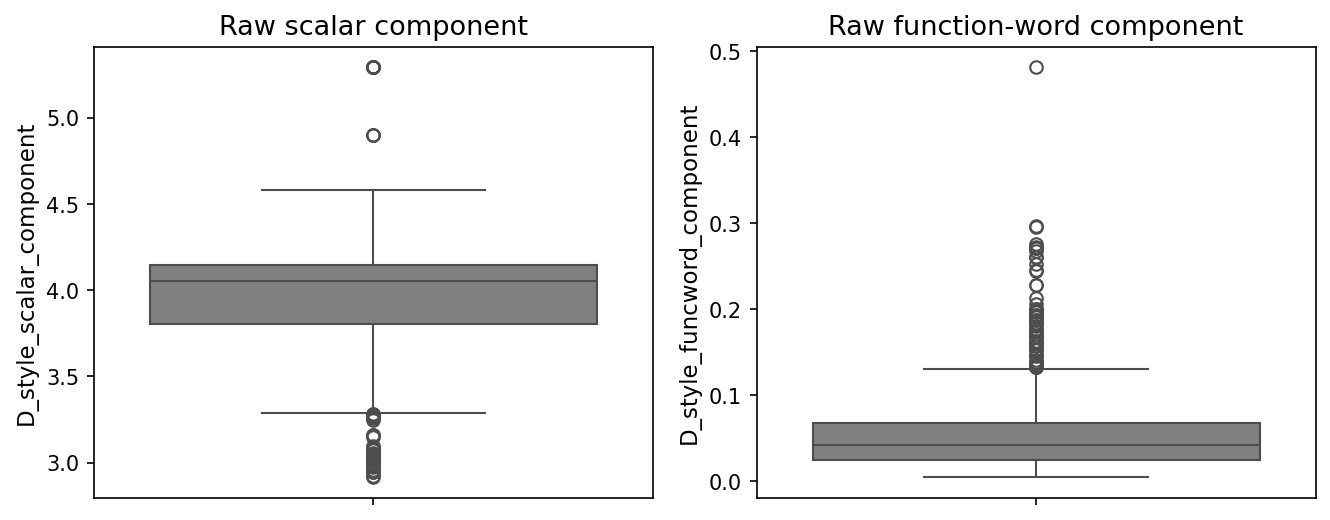

In [53]:
# Compute IQR bounds for outlier detection
def iqr_bounds(series: pd.Series, k: float = 1.5) -> tuple[float, float]:
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

# Report outliers for a given column in the D_style DataFrame
def report_outliers(df: pd.DataFrame, col: str, k: float = 1.5) -> pd.DataFrame:

    # Compute IQR bounds and identify outliers
    lower, upper = iqr_bounds(df[col], k)
    outliers = df[(df[col] < lower) | (df[col] > upper)]


    print(f"{col}: bounds=[{lower:.4f}, {upper:.4f}] (Q1 - {k}*IQR, Q3 + {k}*IQR)")
    print(f"  -> {len(outliers)} outlier(s) ({len(outliers) / len(df):.1%} of {len(df)} observations)")
    return outliers.sort_values(col)[['prompt_id', 'source', col]]

scalar_outliers = report_outliers(df_style, 'D_style_scalar_component')
fw_outliers = report_outliers(df_style, 'D_style_funcword_component')

print("\nScalar component outliers:")
display(scalar_outliers)
print("\nFunction-word component outliers:")
display(fw_outliers)

scalar_outliers.to_csv(TABLE_DIR / 'outliers_scalar_component.csv', index=False)
fw_outliers.to_csv(TABLE_DIR / 'outliers_funcword_component.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
sns.boxplot(y=df_style['D_style_scalar_component'], ax=axes[0], color='gray')
axes[0].set_title('Raw scalar component')
sns.boxplot(y=df_style['D_style_funcword_component'], ax=axes[1], color='gray')
axes[1].set_title('Raw function-word component')
plt.tight_layout()
plt.savefig(FIG_DIR / 'd_style_boxplots_outliers_before.png', dpi=300, bbox_inches='tight')
plt.show()


-> Scalar-Component: all on the lower bound and mostly AI-stories  
-> Function-Word-Component: all on the upper bound and mostly human stories

In [ ]:
# Winsorize both components at (Q1 - 1.5*IQR, Q3 + 1.5*IQR), then min-max normalize to [0,1].

def winsorized_minmax(series: pd.Series, k: float = 1.5) -> pd.Series:
    
    # Get IQR bounds
    lower, upper = iqr_bounds(series, k)
    # Clip values outside the bounds
    clipped = series.clip(lower, upper)
    # Min-max normalize to [0,1]
    return (clipped - clipped.min()) / (clipped.max() - clipped.min())

df_style['scalar_norm'] = winsorized_minmax(df_style['D_style_scalar_component'])
df_style['fw_norm']     = winsorized_minmax(df_style['D_style_funcword_component'])
df_style['D_style']     = 0.5 * df_style['scalar_norm'] + 0.5 * df_style['fw_norm']

print(f"Normalized scalar range: [{df_style['scalar_norm'].min():.4f}, {df_style['scalar_norm'].max():.4f}]")
print(f"Normalized FW range: [{df_style['fw_norm'].min():.4f}, {df_style['fw_norm'].max():.4f}]")

d_style_descriptives = df_style.groupby('source')['D_style'].describe().round(4)
d_style_descriptives.to_csv(TABLE_DIR / 'd_style_descriptives_by_source.csv')
d_style_descriptives


Normalized scalar range: [0.0000, 1.0000]
Normalized FW range: [0.0000, 1.0000]


,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
gemma,196.0,0.3504,0.1718,0.0355,0.2409,0.3342,0.4599,0.9087
human,200.0,0.6725,0.1949,0.2045,0.5069,0.6872,0.8302,0.9692
llama,200.0,0.4022,0.1630,0.0309,0.3026,0.4050,0.5082,0.8174
mistral,200.0,0.3710,0.1742,0.0438,0.2738,0.3923,0.4771,0.9404
qwen,181.0,0.3850,0.1755,0.0075,0.2869,0.3750,0.5010,0.8158


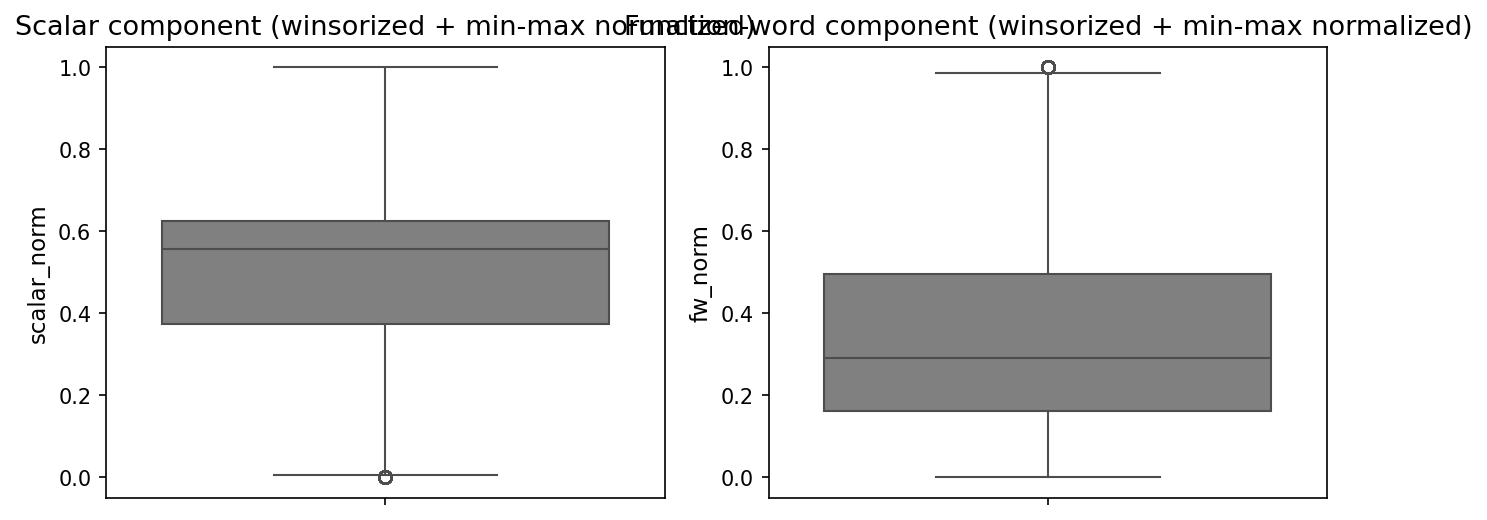

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
sns.boxplot(y=df_style['scalar_norm'], ax=axes[0], color='gray')
axes[0].set_title('Scalar component (winsorized + min-max normalized)')
sns.boxplot(y=df_style['fw_norm'], ax=axes[1], color='gray')
axes[1].set_title('Function-word component (winsorized + min-max normalized)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'd_style_boxplots_outliers_after.png', dpi=300, bbox_inches='tight')
plt.show()


## Descriptive Analysis

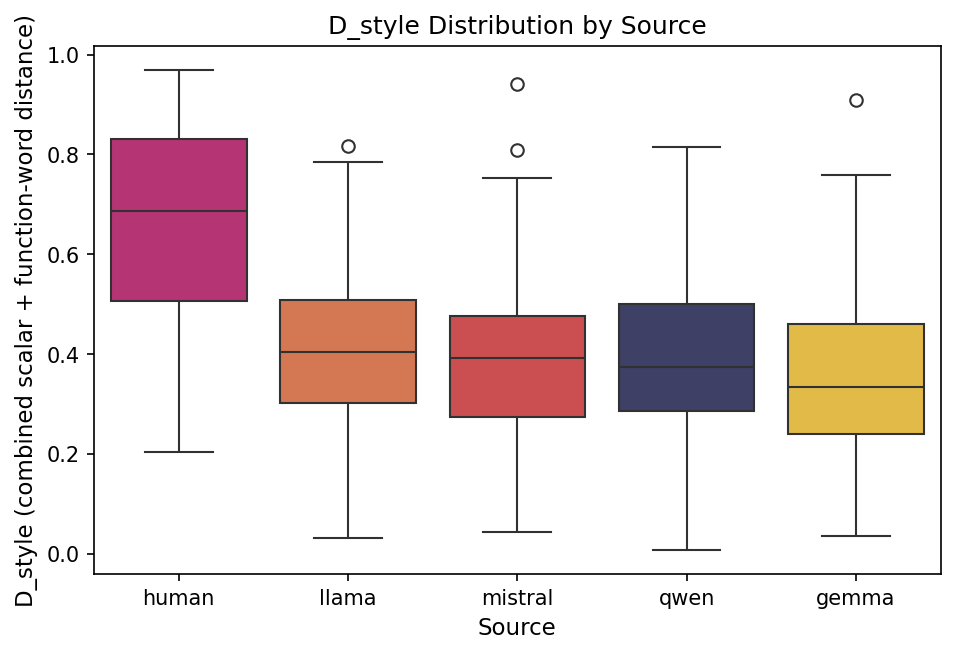

,mean,std
source,,
human,0.6725,0.1949
llama,0.4022,0.1630
mistral,0.3710,0.1742
qwen,0.3850,0.1755
gemma,0.3504,0.1718


In [56]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))

source_order = df_style.groupby('source')['D_style'].median().sort_values(ascending=False).index.tolist()
sns.boxplot(data=df_style, x='source', y='D_style', order=source_order,
            palette=[SOURCE_COLORS[s] for s in source_order], ax=ax)
ax.set_title('D_style Distribution by Source', fontsize=12)
ax.set_xlabel('Source')
ax.set_ylabel('D_style (combined scalar + function-word distance)')

plt.tight_layout()
plt.savefig(FIG_DIR / 'd_style_boxplots_combined.png', dpi=300, bbox_inches='tight')
plt.show()

d_style_mean_std = df_style.groupby('source')['D_style'].agg(['mean', 'std']).reindex(source_order).round(4)
d_style_mean_std.to_csv(TABLE_DIR / 'd_style_mean_std_by_source.csv')
d_style_mean_std


## Component Breakdown

Compare the function-word component vs. the scalar-feature component to see which drives D_style per source

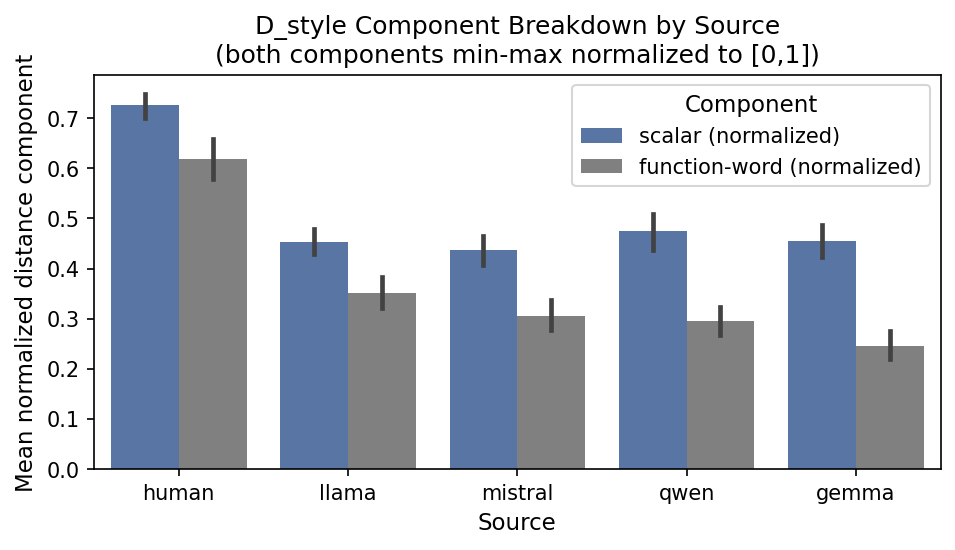

In [57]:
component_df = df_style.melt(
    id_vars=['prompt_id', 'source'],
    value_vars=['scalar_norm', 'fw_norm'],
    var_name='component', value_name='value'
)
component_df['component'] = component_df['component'].map({
    'scalar_norm': 'scalar (normalized)',
    'fw_norm':     'function-word (normalized)'
})

fig, ax = plt.subplots(figsize=(6.5, 3.8))
sns.barplot(data=component_df, x='source', y='value', hue='component',
            order=source_order, ax=ax, palette=['#4C72B0', 'gray'])
ax.set_title('D_style Component Breakdown by Source\n(both components min-max normalized to [0,1])', fontsize=12)
ax.set_xlabel('Source')
ax.set_ylabel('Mean normalized distance component')
ax.legend(title='Component')
plt.tight_layout()
plt.savefig(FIG_DIR / 'd_style_component_breakdown.png', dpi=300, bbox_inches='tight')
plt.show()

## Individual Feature Distributions

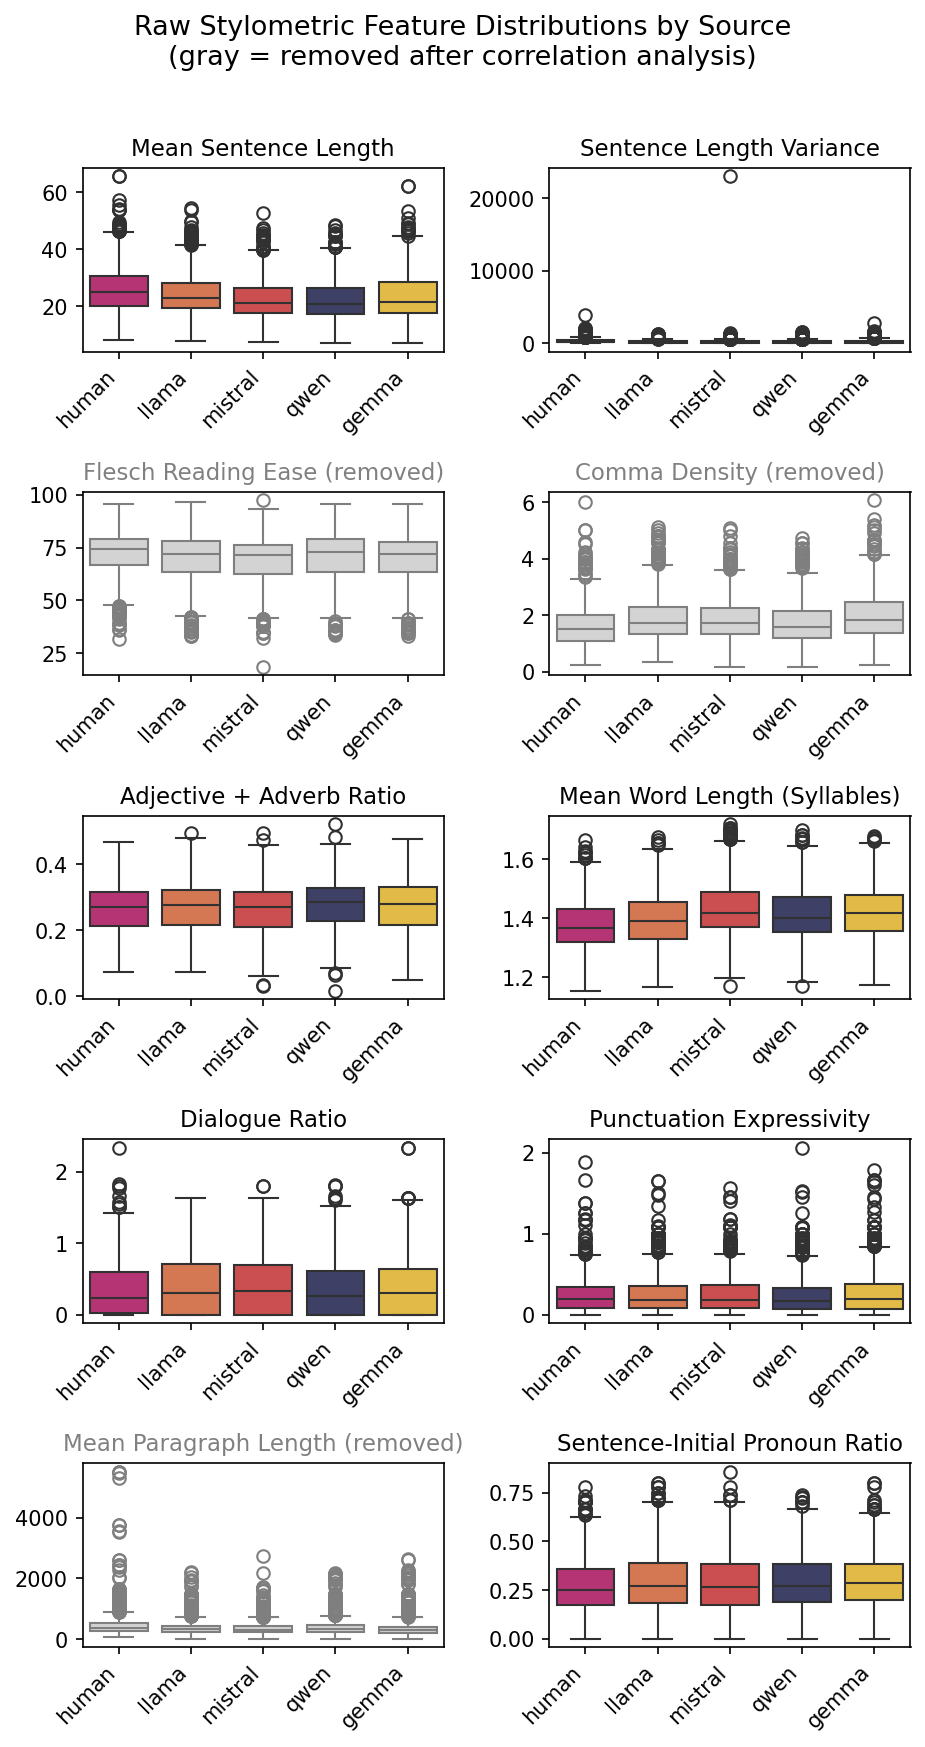

In [58]:
n_features = len(scalar_feature_names)
n_rows, n_cols = 5, 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.15, n_rows * 2.3))
axes = axes.flatten()

for ax, fname in zip(axes, scalar_feature_names):
    is_removed = fname in REDUNDANT_FEATURES
    palette = ['lightgray'] * len(source_order) if is_removed else [SOURCE_COLORS[s] for s in source_order]
    sns.boxplot(data=df_valid, x='source', y=fname, order=source_order, palette=palette, ax=ax)
    label = FEATURE_LABELS[fname]
    title_kwargs = {'color': 'gray'} if is_removed else {}
    ax.set_title(f'{label} (removed)' if is_removed else label, fontsize=11, **title_kwargs)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Hide any unused subplots
for ax in axes[n_features:]:
    ax.set_visible(False)

fig.suptitle('Raw Stylometric Feature Distributions by Source\n(gray = removed after correlation analysis)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'raw_stylometric_features_by_source.png', dpi=300, bbox_inches='tight')
plt.show()


## Statistical Testing: Does Source Affect D_style?

In [61]:
from itertools import combinations as combos

groups = [df_style[df_style['source'] == s]['D_style'].values for s in SOURCES]

# Kruskal-Wallis test across sources
stat, p = kruskal(*groups)
print("Kruskal-Wallis test across sources:")
print(f"  H = {stat:.4f}, p = {p:.4f}")
if p < 0.05:
    print("  -> Significant difference in D_style across sources (p < 0.05)")
else:
    print("  -> No significant difference detected (p >= 0.05)")

pd.DataFrame([{'H': stat, 'p': p}]).to_csv(TABLE_DIR / 'd_style_kruskal_wallis.csv', index=False)

print("\nPairwise Mann-Whitney U tests (Bonferroni corrected):")
pairs = list(combos(SOURCES, 2))
alpha_corrected = 0.05 / len(pairs)
print(f"  Bonferroni threshold: p < {alpha_corrected:.4f}")

# Perform pairwise Mann-Whitney U tests
mw_rows = []
for s1, s2 in pairs:
    g1 = df_style[df_style['source'] == s1]['D_style'].values
    g2 = df_style[df_style['source'] == s2]['D_style'].values
    u, p_mw = mannwhitneyu(g1, g2, alternative='two-sided')
    sig = '***' if p_mw < alpha_corrected else ('*' if p_mw < 0.05 else 'ns')
    print(f"  {s1:10s} vs {s2:10s}: U={u:.0f}, p={p_mw:.4f}  {sig}")
    mw_rows.append({'source_1': s1, 'source_2': s2, 'U': u, 'p': p_mw, 'sig': sig})

pd.DataFrame(mw_rows).to_csv(TABLE_DIR / 'd_style_mannwhitney_pairwise.csv', index=False)


Kruskal-Wallis test across sources:
  H = 264.2836, p = 0.0000
  -> Significant difference in D_style across sources (p < 0.05)

Pairwise Mann-Whitney U tests (Bonferroni corrected):
  Bonferroni threshold: p < 0.0050
  human      vs llama     : U=33904, p=0.0000  ***
  human      vs mistral   : U=34806, p=0.0000  ***
  human      vs qwen      : U=31040, p=0.0000  ***
  human      vs gemma     : U=34771, p=0.0000  ***
  llama      vs mistral   : U=21973, p=0.0880  ns
  llama      vs qwen      : U=19364, p=0.2392  ns
  llama      vs gemma     : U=23495, p=0.0006  ***
  mistral    vs qwen      : U=17650, p=0.6754  ns
  mistral    vs gemma     : U=21547, p=0.0874  ns
  qwen       vs gemma     : U=20090, p=0.0261  *


## Weighting Sensitivity Analysis

- No strong theoretical justification for 0.5/0.5 split between the scalar and function-word component
- Treats two stylistic components as equally important by default.
- Recompute D_style under alternative weightings and check whether the Kruskal-Wallis / Mann-Whitney conclusions above stay the same

In [62]:
# Scalar-component weight; fw weight = 1 - w
WEIGHTS = [0.3, 0.5, 0.7]

sensitivity_results = []
pairwise_pvals = {}

# Vary the weights of the scalar and function-word components
for w in WEIGHTS:
    # Compute weighted D_style for each (prompt_id, source) pair
    d_style_w = w * df_style['scalar_norm'] + (1 - w) * df_style['fw_norm']
    groups_w = [d_style_w[df_style['source'] == s].values for s in SOURCES]
    stat, p_kw = kruskal(*groups_w)
    sensitivity_results.append({'scalar_weight': w, 'fw_weight': round(1 - w, 2), 'KW_H': stat, 'KW_p': p_kw})

    # Pairwise Mann-Whitney U tests for each source pair
    for s1, s2 in pairs:
        g1 = d_style_w[df_style['source'] == s1].values
        g2 = d_style_w[df_style['source'] == s2].values
        _, p_mw = mannwhitneyu(g1, g2, alternative='two-sided')
        pairwise_pvals.setdefault((s1, s2), {})[w] = p_mw

sensitivity_df = pd.DataFrame(sensitivity_results)
sensitivity_df.to_csv(TABLE_DIR / 'd_style_weight_sensitivity_kw.csv', index=False)
print("Kruskal-Wallis across weightings:")
display(sensitivity_df)

pairwise_df = pd.DataFrame(pairwise_pvals).T
pairwise_df.columns = [f'w={w}' for w in pairwise_df.columns]
pairwise_df.index = [f'{s1} vs {s2}' for s1, s2 in pairwise_df.index]

sig_df = pairwise_df < alpha_corrected
sig_df.to_csv(TABLE_DIR / 'd_style_weight_sensitivity_significance.csv')
print(f"\nSignificant at Bonferroni threshold p < {alpha_corrected:.4f}:")
display(sig_df)


Kruskal-Wallis across weightings:


,scalar_weight,fw_weight,KW_H,KW_p
0,0.3,0.7,247.507440,2.241278e-52
1,0.5,0.5,264.283594,5.443285e-56
2,0.7,0.3,268.084615,8.253447e-57



Significant at Bonferroni threshold p < 0.0050:


,w=0.3,w=0.5,w=0.7
human vs llama,True,True,True
human vs mistral,True,True,True
human vs qwen,True,True,True
human vs gemma,True,True,True
llama vs mistral,False,False,False
llama vs qwen,False,False,False
llama vs gemma,True,True,False
mistral vs qwen,False,False,False
mistral vs gemma,False,False,False
qwen vs gemma,False,False,False


## Component Breakdown of Weighting-Sensitive Pairs

In [63]:
def component_kw_mw(df: pd.DataFrame, col: str) -> pd.DataFrame:
    '''
    Perform Kruskal-Wallis test and pairwise Mann-Whitney U tests for a given component column.
    Returns a DataFrame with pairwise p-values and significance flags.
    '''
    # Kruskal-Wallis test across all sources
    groups_c = [df[df['source'] == s][col].values for s in SOURCES]
    stat, p_kw = kruskal(*groups_c)
    print(f"{col}: Kruskal-Wallis H={stat:.4f}, p={p_kw:.4g}")

    # Pairwise Mann-Whitney U tests
    rows = []
    for s1, s2 in pairs:
        g1 = df[df['source'] == s1][col].values
        g2 = df[df['source'] == s2][col].values
        _, p_mw = mannwhitneyu(g1, g2, alternative='two-sided')
        rows.append({'pair': f'{s1} vs {s2}', col: p_mw, f'{col}_sig': p_mw < alpha_corrected})
    return pd.DataFrame(rows).set_index('pair')

scalar_breakdown = component_kw_mw(df_style, 'scalar_norm')
fw_breakdown = component_kw_mw(df_style, 'fw_norm')

breakdown_df = scalar_breakdown.join(fw_breakdown)
breakdown_df.to_csv(TABLE_DIR / 'd_style_component_breakdown_significance.csv')
print()
display(breakdown_df.round(4))

# Pairs whose significance flips across the weightings tested in the sensitivity
# analysis above (derived from sig_df, not hardcoded, so this stays correct if the
# underlying features change and the sensitive pairs shift)
unstable_pairs = sig_df.index[sig_df.nunique(axis=1) > 1].tolist()
print(f"\nWeighting-sensitive pairs ({len(unstable_pairs)}), explained by component:")
for pair in unstable_pairs:
    row = breakdown_df.loc[pair]
    print(f"  {pair}: scalar {'sig' if row['scalar_norm_sig'] else 'ns'} (p={row['scalar_norm']:.4f})"
          f"  |  function-word {'sig' if row['fw_norm_sig'] else 'ns'} (p={row['fw_norm']:.4f})")


scalar_norm: Kruskal-Wallis H=248.1123, p=1.66e-52
fw_norm: Kruskal-Wallis H=206.3572, p=1.614e-43



,scalar_norm,scalar_norm_sig,fw_norm,fw_norm_sig
pair,,,,
human vs llama,0.0000,True,0.0000,True
human vs mistral,0.0000,True,0.0000,True
human vs qwen,0.0000,True,0.0000,True
human vs gemma,0.0000,True,0.0000,True
llama vs mistral,0.1723,False,0.0179,False
llama vs qwen,0.4743,False,0.0104,False
llama vs gemma,0.1398,False,0.0000,True
mistral vs qwen,0.0847,False,0.9350,False
mistral vs gemma,0.9015,False,0.0015,True



Weighting-sensitive pairs (1), explained by component:
  llama vs gemma: scalar ns (p=0.1398)  |  function-word sig (p=0.0000)


## Export Results

In [64]:
out_path = TABLE_DIR / 'D_style_results.csv'

# Summary: only prompt_id, source, n_texts, D_style
df_style[['prompt_id', 'source', 'n_texts', 'D_style']].to_csv(
    TABLE_DIR / 'D_style_results_summary.csv', index=False
)

# Full: include raw and normalized components for transparency
df_style.to_csv(out_path, index=False)

print(f"Saved D_style results to: {out_path}")
df_style.head(10)

Saved D_style results to: ../../metrics/02_stylistic_diversity/tables/translation_ref3/D_style_results.csv


,prompt_id,source,n_texts,D_style_scalar_component,D_style_funcword_component,scalar_norm,fw_norm,D_style
0,0,gemma,5,4.061779,0.018208,0.562242,0.105166,0.333704
1,0,human,3,4.415657,0.049773,0.818056,0.352965,0.585511
2,0,llama,5,3.999392,0.031641,0.517143,0.210623,0.363883
3,0,mistral,5,3.952416,0.043178,0.483184,0.301196,0.392190
4,0,qwen,5,4.092250,0.028563,0.584269,0.186462,0.385365
5,1,gemma,5,3.862187,0.015611,0.417958,0.084780,0.251369
6,1,human,4,4.232608,0.050342,0.685732,0.357435,0.521583
7,1,llama,5,4.089582,0.036183,0.582340,0.246279,0.414309
8,1,mistral,5,3.915100,0.013383,0.456209,0.067291,0.261750
9,1,qwen,5,4.051885,0.020355,0.555089,0.122021,0.338555
